In [2]:
import requests
import json 
from pprint import pprint 
import seaborn as sns
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib


In [3]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"start_date": "2000-01-01",
	"end_date": "2026-02-06",
	"daily": ["weather_code", "temperature_2m_mean", "precipitation_sum", "daylight_duration", "sunshine_duration", "apparent_temperature_mean", "sunrise", "sunset", "rain_sum", "snowfall_sum", "precipitation_hours", "wind_direction_10m_dominant", "relative_humidity_2m_mean", "pressure_msl_mean", "dew_point_2m_mean", "cloud_cover_mean", "surface_pressure_mean", "wind_gusts_10m_mean", "wind_speed_10m_mean"],
	"timezone": "America/Chicago",
}
response = requests.get(url, params=params)

print(response.status_code)
print(response.headers.get("Content-Type"))
print(response.text[:200])  

data = response.json()

200
application/json; charset=utf-8
{"latitude":52.54833,"longitude":13.407822,"generationtime_ms":1022.208571434021,"utc_offset_seconds":-21600,"timezone":"America/Chicago","timezone_abbreviation":"GMT-6","elevation":38.0,"daily_units"


In [4]:
for r in response.json():
    print(r)

latitude
longitude
generationtime_ms
utc_offset_seconds
timezone
timezone_abbreviation
elevation
daily_units
daily


In [5]:
weather_df = pd.DataFrame(response.json()['daily'])
weather_df.head()

,time,weather_code,temperature_2m_mean,precipitation_sum,daylight_duration,sunshine_duration,apparent_temperature_mean,sunrise,sunset,rain_sum,snowfall_sum,precipitation_hours,wind_direction_10m_dominant,relative_humidity_2m_mean,pressure_msl_mean,dew_point_2m_mean,cloud_cover_mean,surface_pressure_mean,wind_gusts_10m_mean,wind_speed_10m_mean
0,2000-01-01,71,1.8,2.5,27884.61,0.00,-1.6,2000-01-01T01:17,2000-01-01T09:01,1.9,0.42,9.0,235,96,1022.6,1.2,100,1017.8,19.4,10.3
1,2000-01-02,3,3.6,0.0,27958.83,0.00,-0.2,2000-01-02T01:17,2000-01-02T09:02,0.0,0.00,0.0,248,93,1026.2,2.5,100,1021.4,28.3,14.7
2,2000-01-03,51,5.7,0.2,28039.85,0.00,1.4,2000-01-03T01:17,2000-01-03T09:03,0.2,0.00,2.0,235,84,1019.9,3.1,100,1015.1,35.3,18.7
3,2000-01-04,55,5.5,4.7,28127.45,2097.16,1.6,2000-01-04T01:16,2000-01-04T09:05,4.7,0.00,11.0,236,90,1014.5,4.0,94,1009.8,33.1,17.1
4,2000-01-05,3,1.6,0.0,28221.39,21833.25,-2.7,2000-01-05T01:16,2000-01-05T09:06,0.0,0.00,0.0,246,84,1020.8,-0.8,52,1016.0,28.6,14.3


In [6]:
weather_df.shape

(9534, 20)

In [7]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9534 entries, 0 to 9533
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         9534 non-null   object 
 1   weather_code                 9534 non-null   int64  
 2   temperature_2m_mean          9534 non-null   float64
 3   precipitation_sum            9534 non-null   float64
 4   daylight_duration            9534 non-null   float64
 5   sunshine_duration            9534 non-null   float64
 6   apparent_temperature_mean    9534 non-null   float64
 7   sunrise                      9534 non-null   object 
 8   sunset                       9534 non-null   object 
 9   rain_sum                     9534 non-null   float64
 10  snowfall_sum                 9534 non-null   float64
 11  precipitation_hours          9534 non-null   float64
 12  wind_direction_10m_dominant  9534 non-null   int64  
 13  relative_humidity_

In [8]:
weather_df.describe()

,weather_code,temperature_2m_mean,precipitation_sum,daylight_duration,sunshine_duration,apparent_temperature_mean,rain_sum,snowfall_sum,precipitation_hours,wind_direction_10m_dominant,relative_humidity_2m_mean,pressure_msl_mean,dew_point_2m_mean,cloud_cover_mean,surface_pressure_mean,wind_gusts_10m_mean,wind_speed_10m_mean
count,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000,9534.000000
mean,33.973883,10.279411,1.692385,44156.964077,26532.065024,7.666656,1.576159,0.087790,3.584749,199.123872,75.795993,1015.503377,5.684854,66.944619,1010.861684,25.741903,12.816530
std,27.523391,7.822545,3.536433,11269.265851,17169.424800,9.315783,3.478926,0.465433,4.786746,90.975753,12.498888,9.044767,6.441319,27.359503,8.990947,9.444250,5.026514
min,0.000000,-18.000000,0.000000,27513.480000,0.000000,-23.200000,0.000000,0.000000,0.000000,0.000000,29.000000,974.100000,-22.400000,0.000000,969.500000,5.100000,2.100000
25%,3.000000,4.300000,0.000000,33325.370000,11652.102500,0.200000,0.000000,0.000000,0.000000,121.000000,67.000000,1010.000000,1.200000,49.000000,1005.400000,18.900000,9.100000
50%,51.000000,10.300000,0.200000,44233.450000,27572.315000,7.400000,0.100000,0.000000,1.000000,223.000000,77.000000,1015.700000,6.000000,73.000000,1011.100000,24.000000,12.000000
75%,53.000000,16.600000,1.900000,54983.462500,41791.782500,15.200000,1.700000,0.000000,6.000000,268.000000,86.000000,1021.100000,10.700000,90.000000,1016.500000,30.900000,15.600000
max,75.000000,30.800000,120.700000,60626.600000,55590.410000,31.200000,120.700000,9.800000,24.000000,360.000000,99.000000,1047.400000,21.200000,100.000000,1042.100000,73.500000,36.100000


In [9]:
weather_df.isna().head()

,time,weather_code,temperature_2m_mean,precipitation_sum,daylight_duration,sunshine_duration,apparent_temperature_mean,sunrise,sunset,rain_sum,snowfall_sum,precipitation_hours,wind_direction_10m_dominant,relative_humidity_2m_mean,pressure_msl_mean,dew_point_2m_mean,cloud_cover_mean,surface_pressure_mean,wind_gusts_10m_mean,wind_speed_10m_mean
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
weather_df.isna().sum()

time                           0
weather_code                   0
temperature_2m_mean            0
precipitation_sum              0
daylight_duration              0
sunshine_duration              0
apparent_temperature_mean      0
sunrise                        0
sunset                         0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_direction_10m_dominant    0
relative_humidity_2m_mean      0
pressure_msl_mean              0
dew_point_2m_mean              0
cloud_cover_mean               0
surface_pressure_mean          0
wind_gusts_10m_mean            0
wind_speed_10m_mean            0
dtype: int64

In [11]:
weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df["year"] = weather_df["time"].dt.year
weather_df["month"] = weather_df["time"].dt.month
weather_df["day"] = weather_df["time"].dt.day

weather_df.head()

,time,weather_code,temperature_2m_mean,precipitation_sum,daylight_duration,sunshine_duration,apparent_temperature_mean,sunrise,sunset,rain_sum,...,relative_humidity_2m_mean,pressure_msl_mean,dew_point_2m_mean,cloud_cover_mean,surface_pressure_mean,wind_gusts_10m_mean,wind_speed_10m_mean,year,month,day
0,2000-01-01,71,1.8,2.5,27884.61,0.00,-1.6,2000-01-01T01:17,2000-01-01T09:01,1.9,...,96,1022.6,1.2,100,1017.8,19.4,10.3,2000,1,1
1,2000-01-02,3,3.6,0.0,27958.83,0.00,-0.2,2000-01-02T01:17,2000-01-02T09:02,0.0,...,93,1026.2,2.5,100,1021.4,28.3,14.7,2000,1,2
2,2000-01-03,51,5.7,0.2,28039.85,0.00,1.4,2000-01-03T01:17,2000-01-03T09:03,0.2,...,84,1019.9,3.1,100,1015.1,35.3,18.7,2000,1,3
3,2000-01-04,55,5.5,4.7,28127.45,2097.16,1.6,2000-01-04T01:16,2000-01-04T09:05,4.7,...,90,1014.5,4.0,94,1009.8,33.1,17.1,2000,1,4
4,2000-01-05,3,1.6,0.0,28221.39,21833.25,-2.7,2000-01-05T01:16,2000-01-05T09:06,0.0,...,84,1020.8,-0.8,52,1016.0,28.6,14.3,2000,1,5


In [12]:
weather_df.groupby('month').temperature_2m_mean.agg(['mean','std', 'median', 'count'])

,mean,std,median,count
month,,,,
1,0.813978,4.628783,0.90,837
2,1.857085,4.267200,1.80,741
3,4.712283,3.894144,5.10,806
4,9.620000,3.994625,9.60,780
5,14.419231,3.598432,14.35,806
6,18.288462,3.574147,18.10,780
7,19.812655,3.320576,19.40,806
8,19.660794,3.208192,19.30,806
9,15.482821,3.274433,15.30,780


# Naeliz's Section

This section will cover an extensive EDA

In [ ]:
# Set up to cover time features and seasons

weather_df = weather_df.copy()
weather_df["time"] = pd.to_datetime(weather_df["time"])

weather_df["year"]  = weather_df["time"].dt.year
weather_df["month"] = weather_df["time"].dt.month
weather_df["day"]   = weather_df["time"].dt.day

season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring", 4:"Spring", 5:"Spring",
    6:"Summer", 7:"Summer", 8:"Summer",
    9:"Fall", 10:"Fall", 11:"Fall"
}
weather_df["season"] = weather_df["month"].map(season_map)

weather_df = weather_df.sort_values("time").reset_index(drop=True)
weather_df.head()

,time,weather_code,temperature_2m_mean,precipitation_sum,daylight_duration,sunshine_duration,apparent_temperature_mean,sunrise,sunset,rain_sum,...,pressure_msl_mean,dew_point_2m_mean,cloud_cover_mean,surface_pressure_mean,wind_gusts_10m_mean,wind_speed_10m_mean,year,month,day,season
0,2000-01-01,71,1.8,2.5,27884.61,0.00,-1.6,2000-01-01T01:17,2000-01-01T09:01,1.9,...,1022.6,1.2,100,1017.8,19.4,10.3,2000,1,1,Winter
1,2000-01-02,3,3.6,0.0,27958.83,0.00,-0.2,2000-01-02T01:17,2000-01-02T09:02,0.0,...,1026.2,2.5,100,1021.4,28.3,14.7,2000,1,2,Winter
2,2000-01-03,51,5.7,0.2,28039.85,0.00,1.4,2000-01-03T01:17,2000-01-03T09:03,0.2,...,1019.9,3.1,100,1015.1,35.3,18.7,2000,1,3,Winter
3,2000-01-04,55,5.5,4.7,28127.45,2097.16,1.6,2000-01-04T01:16,2000-01-04T09:05,4.7,...,1014.5,4.0,94,1009.8,33.1,17.1,2000,1,4,Winter
4,2000-01-05,3,1.6,0.0,28221.39,21833.25,-2.7,2000-01-05T01:16,2000-01-05T09:06,0.0,...,1020.8,-0.8,52,1016.0,28.6,14.3,2000,1,5,Winter


In [ ]:
# Monthly breakdown 

monthly = weather_df.groupby("month").agg(
    temp_mean=("temperature_2m_mean", "mean"),
    temp_p10=("temperature_2m_mean", lambda x: np.percentile(x, 10)),
    temp_p90=("temperature_2m_mean", lambda x: np.percentile(x, 90)),

    precip_mean=("precipitation_sum", "mean"),
    precip_p90=("precipitation_sum", lambda x: np.percentile(x, 90)),

    wind_mean=("wind_speed_10m_mean", "mean"),
    wind_p90=("wind_speed_10m_mean", lambda x: np.percentile(x, 90)),

    sunshine_mean=("sunshine_duration", "mean"),
    daylight_mean=("daylight_duration", "mean"),

    n_days=("time","count")
).reset_index()

monthly

,month,temp_mean,temp_p10,temp_p90,precip_mean,precip_p90,wind_mean,wind_p90,sunshine_mean,daylight_mean,n_days
0,1,0.813978,-5.10,6.50,1.732497,5.34,14.744803,23.84,10422.310860,29858.705484,837
1,2,1.857085,-3.30,7.20,1.466532,4.80,14.250742,22.50,16740.599514,35713.874561,741
2,3,4.712283,-0.35,9.35,1.411787,4.75,13.368610,21.00,24361.042916,42911.259330,806
3,4,9.620000,4.50,14.91,1.136282,3.61,12.524487,18.50,34955.290103,50348.310962,780
4,5,14.419231,10.00,19.30,1.801117,6.35,12.232506,17.55,39166.381551,56863.965856,806
5,6,18.288462,13.99,23.00,1.960897,5.30,11.818846,17.41,42553.097103,60303.775167,780
6,7,19.812655,15.80,24.50,2.702109,7.65,11.498139,16.80,40198.551166,58505.755769,806
7,8,19.660794,15.70,24.10,1.799007,5.60,11.064020,15.70,38011.799491,52665.518635,806
8,9,15.482821,11.30,19.80,1.596667,5.50,11.942179,18.10,30297.197846,45489.528103,780
9,10,10.609057,6.25,14.70,1.613896,5.50,12.925186,19.85,20300.804603,38110.313598,806


In [ ]:
# Seasonal breakdown

seasonal = weather_df.groupby("season").agg(
    temp_mean=("temperature_2m_mean", "mean"),
    precip_mean=("precipitation_sum", "mean"),
    wind_mean=("wind_speed_10m_mean", "mean"),
    sunshine_mean=("sunshine_duration", "mean"),
    n_days=("time","count")
).reset_index()

seasonal

,season,temp_mean,precip_mean,wind_mean,sunshine_mean,n_days
0,Fall,10.577346,1.584869,12.673035,21201.342494,2366
1,Spring,9.583445,1.453135,12.710535,32804.444147,2392
2,Summer,19.264465,2.156104,11.456438,40229.497646,2392
3,Winter,1.666820,1.573867,14.429950,11785.714274,2384


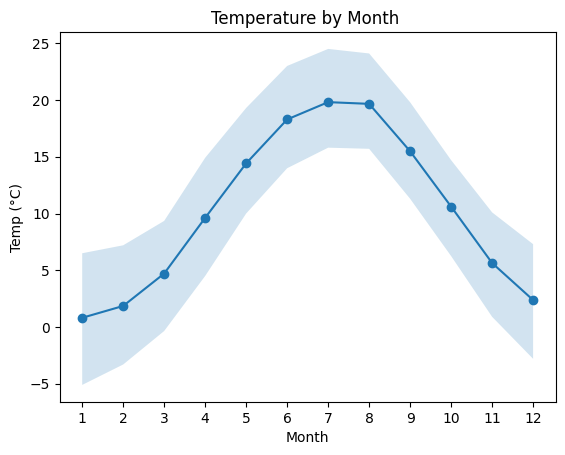

In [ ]:
# Advisory of temperature for a traveler 

plt.figure()
plt.plot(monthly["month"], monthly["temp_mean"], marker="o")
plt.fill_between(monthly["month"], monthly["temp_p10"], monthly["temp_p90"], alpha=0.2)
plt.title("Temperature by Month ")
plt.xlabel("Month")
plt.ylabel("Temp (°C)")
plt.xticks(range(1,13))
plt.show()

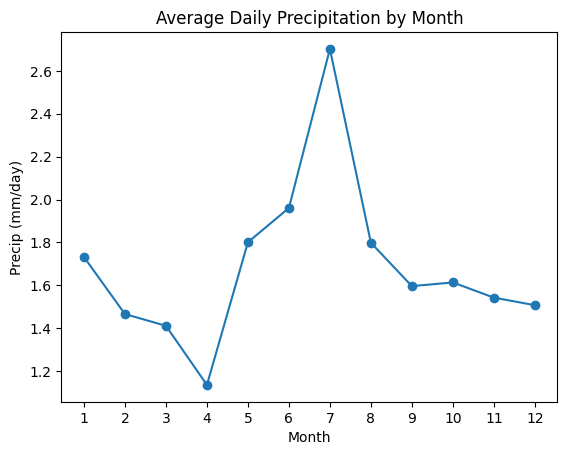

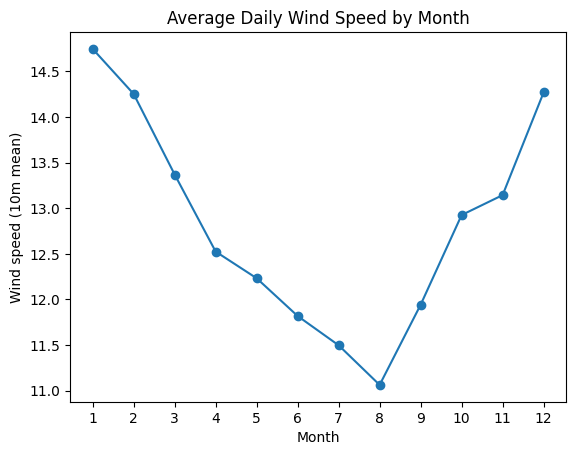

In [26]:
# Rain and wind seasonality (weather planning)

plt.figure()
plt.plot(monthly["month"], monthly["precip_mean"], marker="o")
plt.title("Average Daily Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Precip (mm/day)")
plt.xticks(range(1,13))
plt.show()

plt.figure()
plt.plot(monthly["month"], monthly["wind_mean"], marker="o")
plt.title("Average Daily Wind Speed by Month")
plt.xlabel("Month")
plt.ylabel("Wind speed (10m mean)")
plt.xticks(range(1,13))
plt.show()

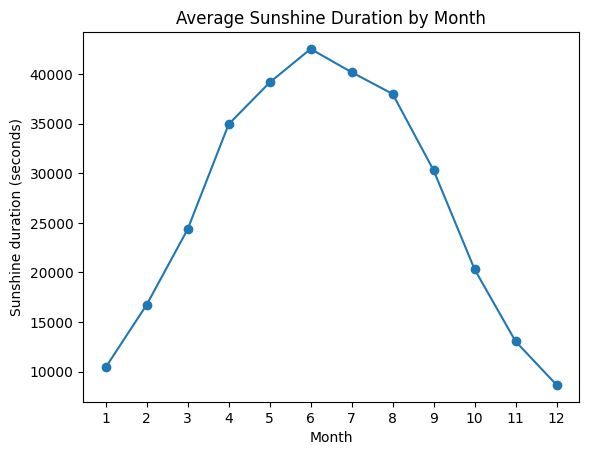

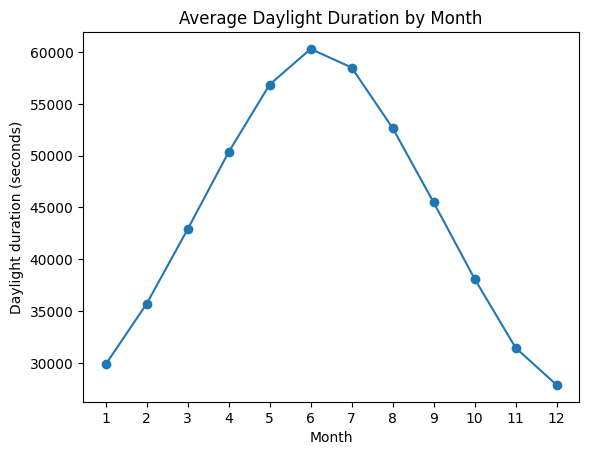

In [27]:
# Sunshine and daylight 

plt.figure()
plt.plot(monthly["month"], monthly["sunshine_mean"], marker="o")
plt.title("Average Sunshine Duration by Month")
plt.xlabel("Month")
plt.ylabel("Sunshine duration (seconds)")
plt.xticks(range(1,13))
plt.show()

plt.figure()
plt.plot(monthly["month"], monthly["daylight_mean"], marker="o")
plt.title("Average Daylight Duration by Month")
plt.xlabel("Month")
plt.ylabel("Daylight duration (seconds)")
plt.xticks(range(1,13))
plt.show()

Correlation and Heat Map plots

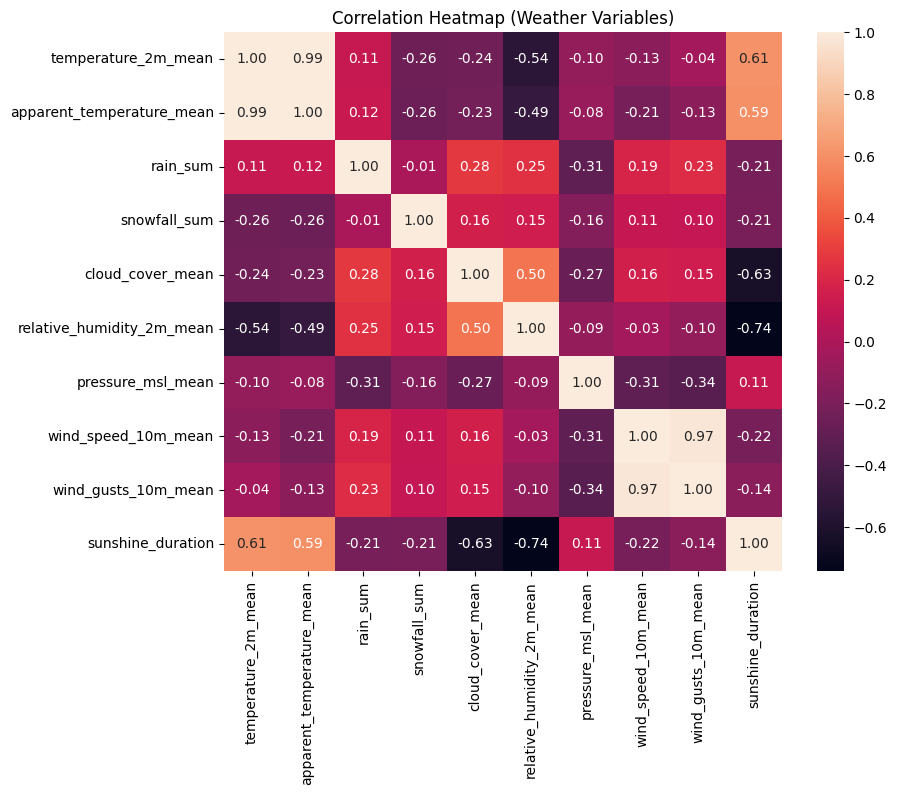

In [ ]:
# Correlation heat map between columns

heat_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "rain_sum",
    "snowfall_sum",
    "cloud_cover_mean",
    "relative_humidity_2m_mean",
    "pressure_msl_mean",
    "wind_speed_10m_mean",
    "wind_gusts_10m_mean",
    "sunshine_duration"]

corr = weather_df[heat_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Weather Variables)")
plt.show()

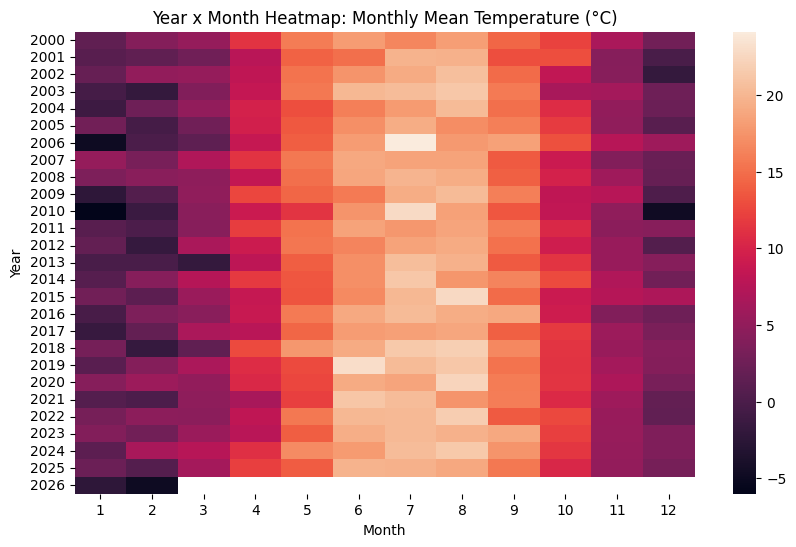

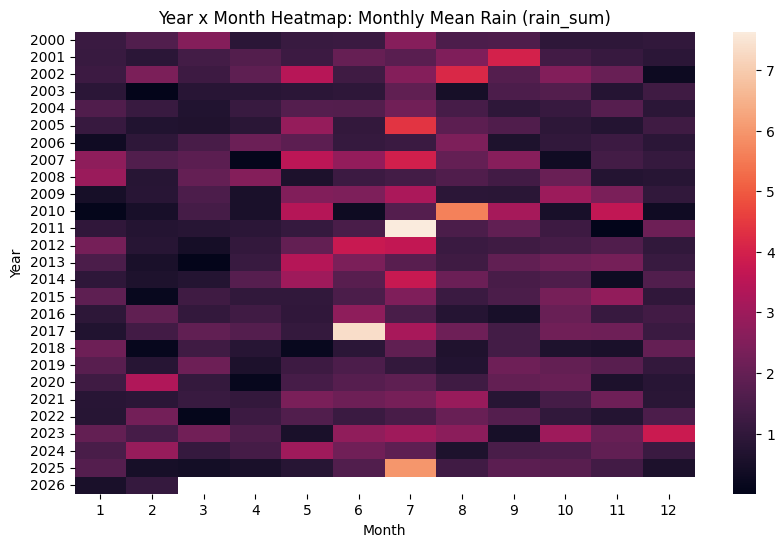

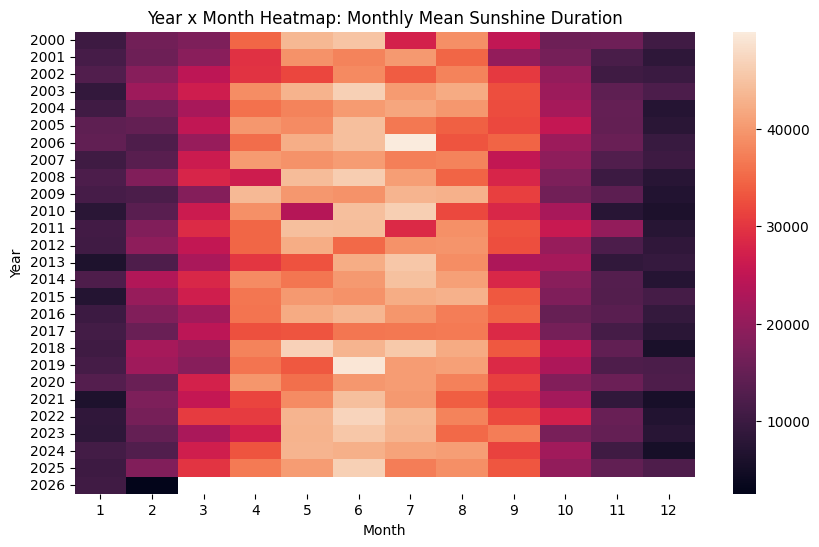

In [33]:
# Pivot plot (Year x month) to do a seperate heatmap for temperature, rain and sunshine

pivotTemp = weather_df.groupby(["year", "month"])["temperature_2m_mean"].mean().unstack()
pivotRain = weather_df.groupby(["year", "month"])["rain_sum"].mean().unstack()
pivotSun  = weather_df.groupby(["year", "month"])["sunshine_duration"].mean().unstack()

# Heatmap 1: Temperature
plt.figure(figsize=(10,6))
sns.heatmap(pivotTemp)
plt.title("Year x Month Heatmap: Monthly Mean Temperature (°C)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

# Heatmap 2: Rain
plt.figure(figsize=(10,6))
sns.heatmap(pivotRain)
plt.title("Year x Month Heatmap: Monthly Mean Rain (rain_sum)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

# Heatmap 3: Sunshine duration
plt.figure(figsize=(10,6))
sns.heatmap(pivotSun)
plt.title("Year x Month Heatmap: Monthly Mean Sunshine Duration")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

Pair plot and histogram of weather variables

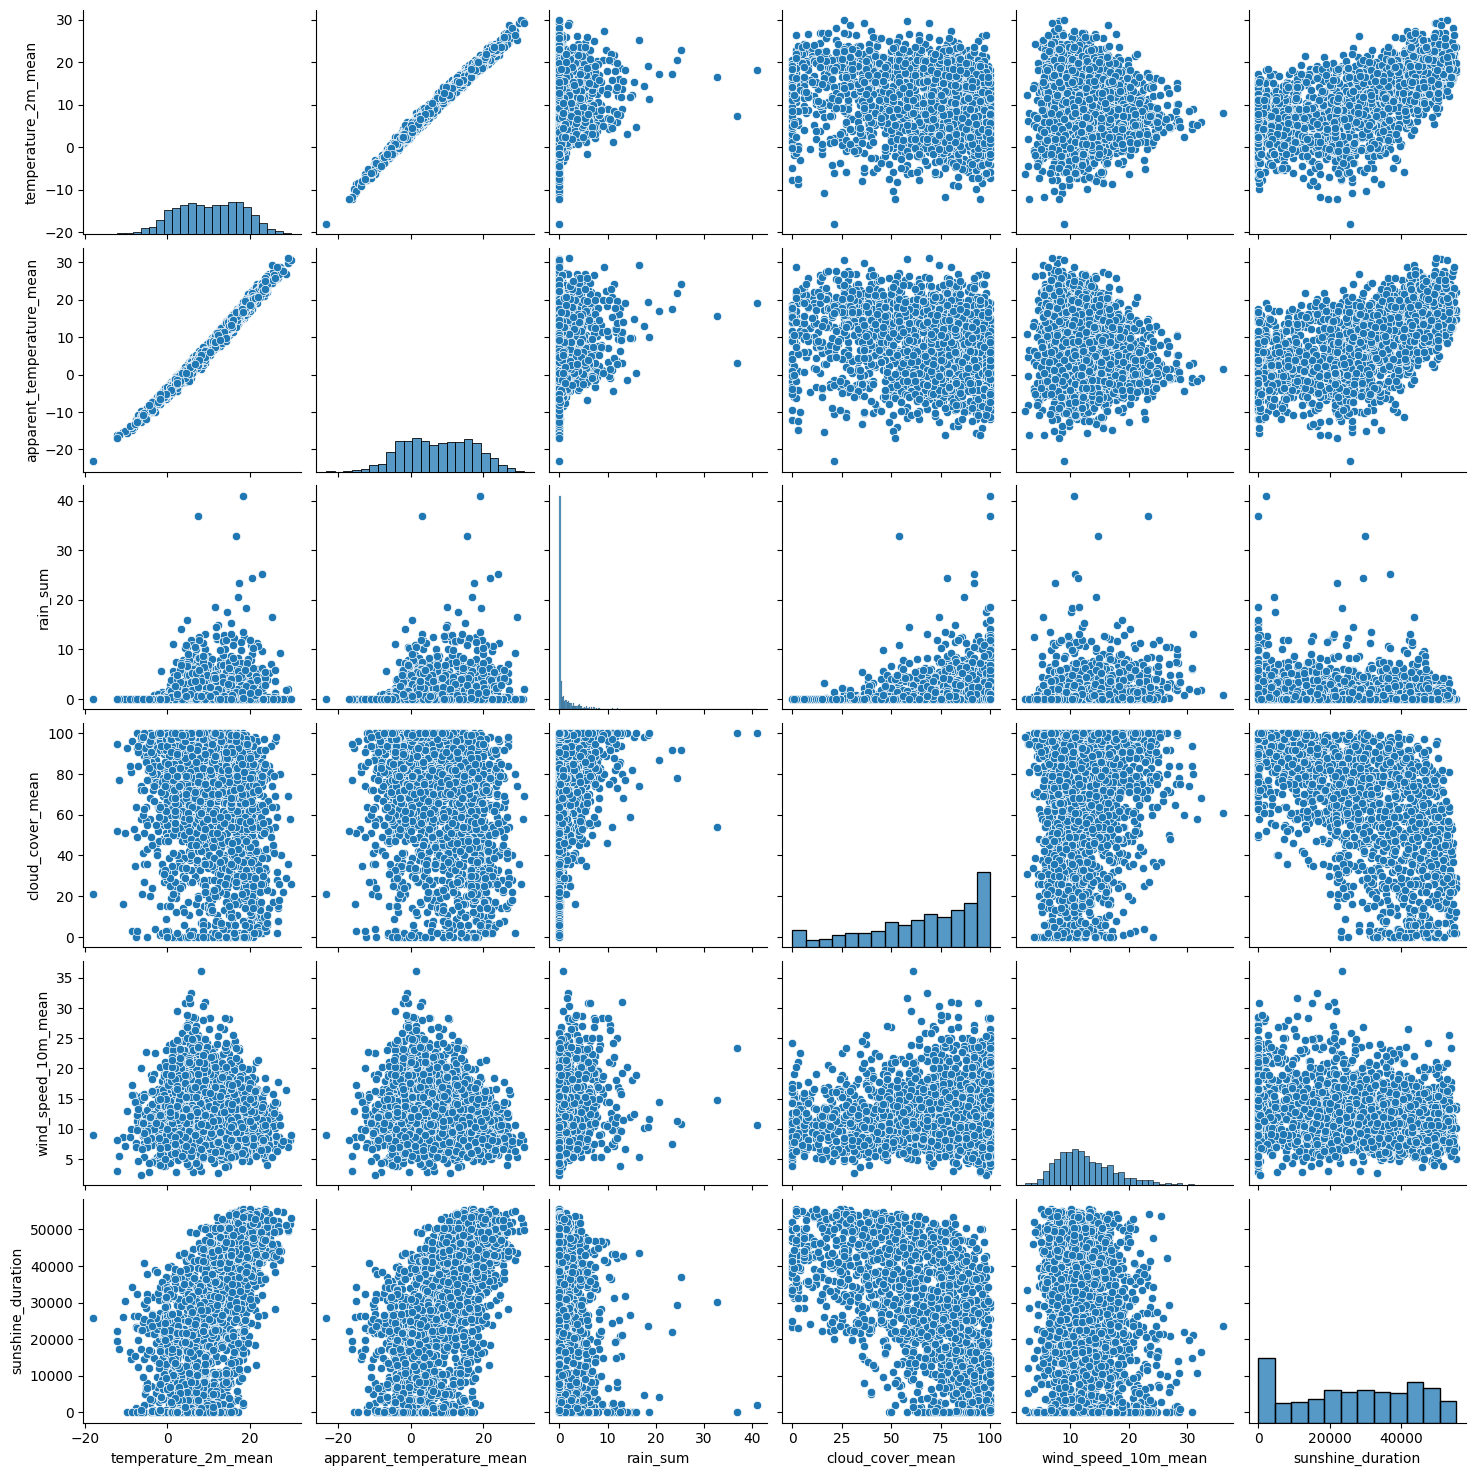

In [34]:
pair_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "rain_sum",
    "cloud_cover_mean",
    "wind_speed_10m_mean",
    "sunshine_duration"]

pair_sample = weather_df[pair_cols].dropna().sample(
    n=min(2000, weather_df.shape[0]),
    random_state=0)

sns.pairplot(pair_sample)
plt.show()

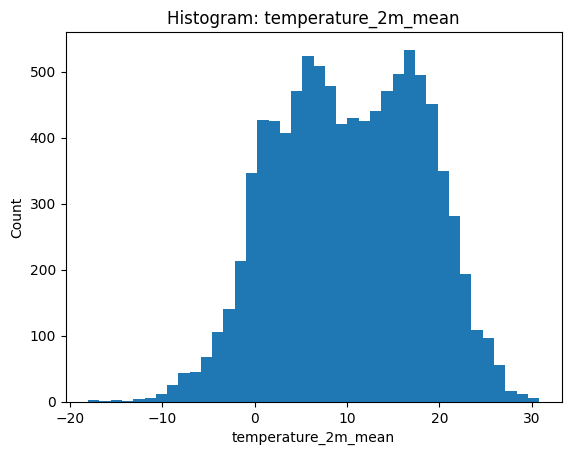

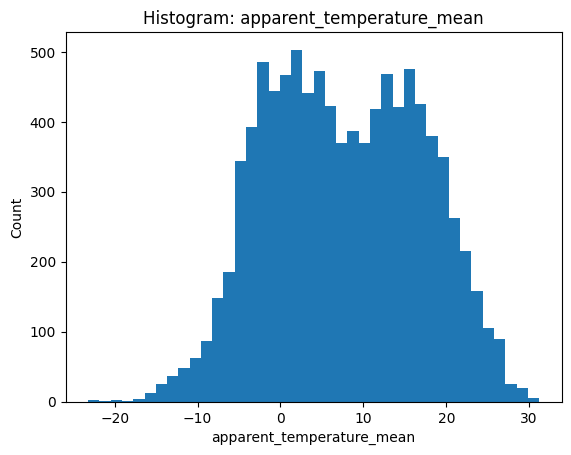

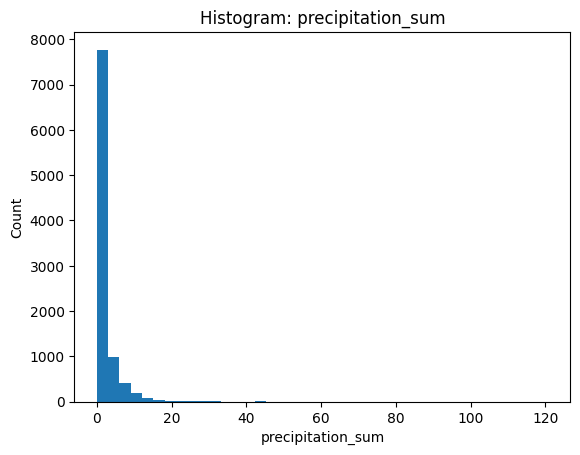

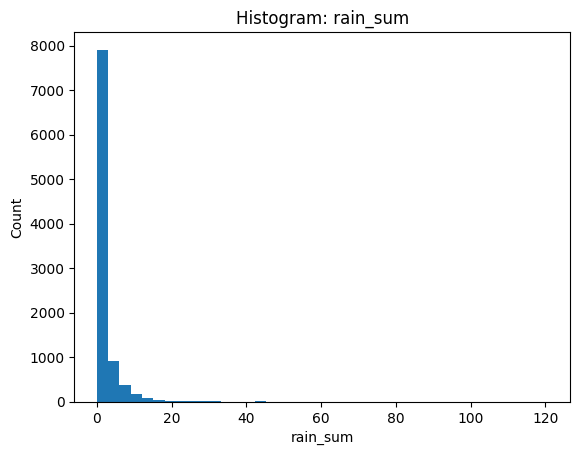

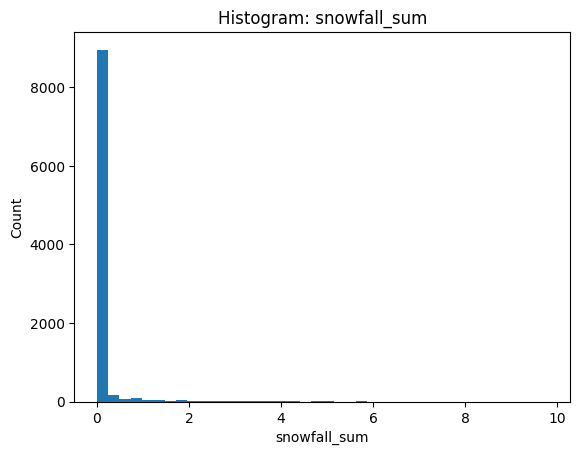

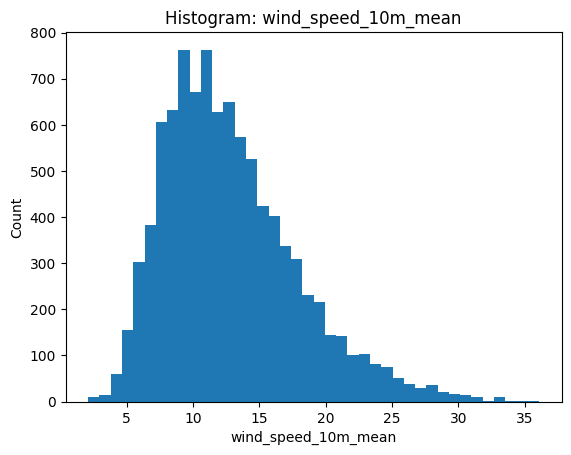

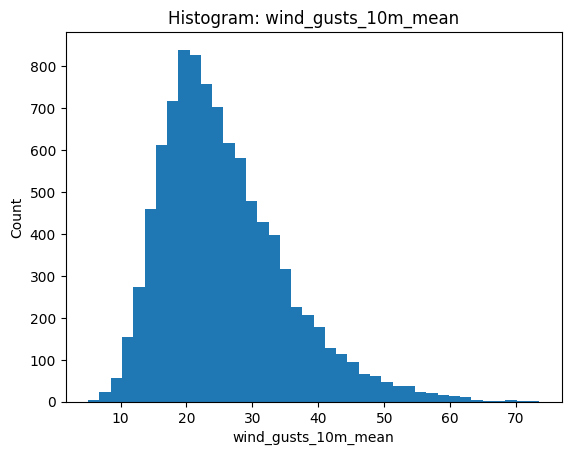

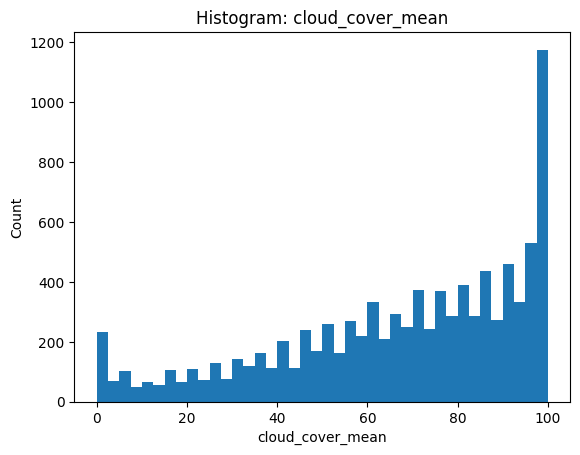

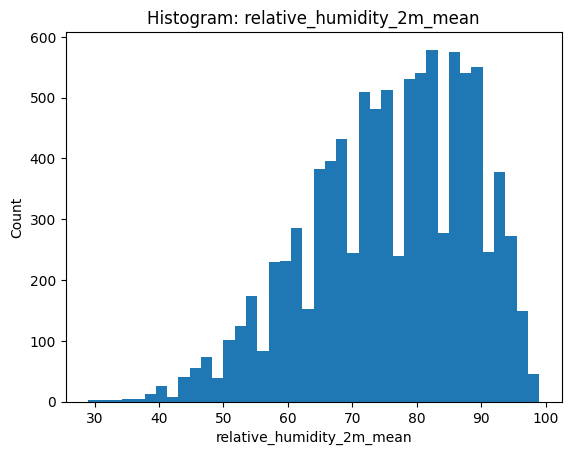

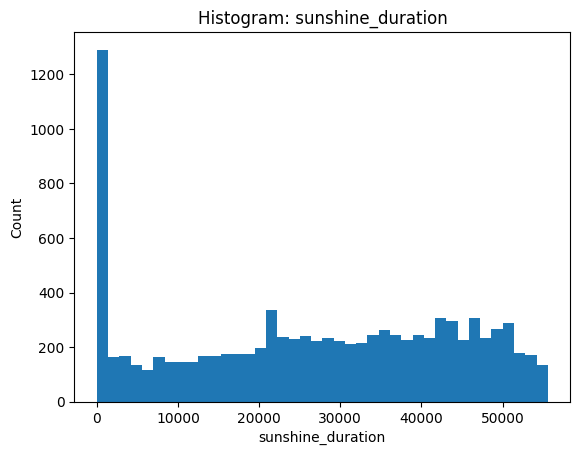

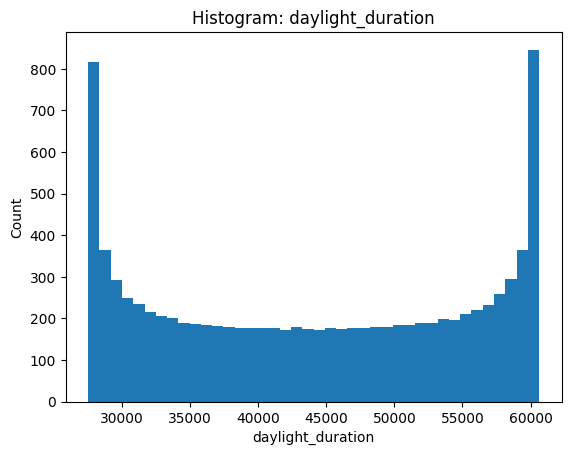

In [35]:
hist_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_mean",
    "wind_gusts_10m_mean",
    "cloud_cover_mean",
    "relative_humidity_2m_mean",
    "sunshine_duration",
    "daylight_duration"]

for col in hist_cols:
    plt.figure()
    plt.hist(weather_df[col].dropna(), bins=40)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()